# 📌 Tugas 8 - Praktikum Data Science

> Copy template ini lalu kerjakan menggunakan template ini.

> Referensi untuk mengerjakan tugas :
> - https://colab.research.google.com/drive/1cCozod_L1um-5E4YDhD2RLoNXRNoylq9?usp=sharing
> - https://colab.research.google.com/drive/1_5ehUVxBed28qwAPLcR0C9aaYoaPiNZ3?usp=sharing
> - https://colab.research.google.com/drive/15KuXtQRyhSbMoimVmi0zjE06e9EwKT6s?usp=sharing
> - https://colab.research.google.com/drive/10BuLMoi9megpSFmn9AcYSXt8z6xCo3hT?usp=sharing

---

Tugas ini bertujuan untuk membantu kalian memahami beberapa teknik Data Science menggunakan data asli.
Silakan download dataset di : https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

- Nama lengkap : Aditya Nugraha Pratama Saiya
- Program : AI Development

Setiap langkah, setiap cell terdapat 'insight' hasil analisis dari kode yang dijalankan. Berikan insight sesuai dengan cell yang dijalankan.

**0. Import module yang diperlukan**

In [173]:
%pip install kagglehub[pandas-datasets]

In [174]:
import kagglehub as kg
import shutil, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [175]:
# Format: "username/dataset-slug" dari URL Kaggle
path = kg.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [176]:
# Salin file CSV ke folder EDA_Dataset
os.makedirs("./EDA_Dataset", exist_ok=True)
for f in os.listdir(path):
    if f.endswith(".csv"):
        shutil.copy(os.path.join(path, f), "./EDA_Dataset/")
        print(f"File disalin: {f}")

File disalin: Housing.csv


**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas, atau teknik lainnya seperti describe()



In [177]:
# Memuat dataset Housing Prices ke dalam DataFrame 'df'
df = pd.read_csv('./EDA_Dataset/Housing.csv')

# Menampilkan 5 data teratas
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [178]:
# Menampilkan 5 data terbawah
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [179]:
# Cek tipe data setiap kolom dan jumlah non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [180]:
# Jumlah nilai null (missing values) per kolom
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [181]:
# Statistik deskriptif kolom numerik (count, mean, std, min, max, dll)
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [182]:
# Statistik deskriptif kolom bertipe string / kategorikal
df.describe(include='object')

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


### Insight - Membaca Data

#### Gambaran Umum Dataset
- **Jumlah data**: 545 baris dan 13 kolom, dataset berukuran kecil namun cukup untuk analisis harga rumah
- **Kolom numerik (6)**: price, area, bedrooms, bathrooms, stories, parking
- **Kolom kategorikal (7)**: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus
- **Missing values**: tidak ditemukan missing values di seluruh kolom (545 non-null semua), data siap digunakan tanpa imputasi

#### Statistik Harga (price)
- **Rata-rata harga**: 4.766.729 | **Median**: 4.340.000
- **Harga minimum**: 1.750.000 | **Harga maksimum**: 13.300.000
- Selisih mean dan median yang tidak terlalu jauh menunjukkan distribusi harga relatif simetris, namun max yang jauh (13.3 juta) mengindikasikan adanya outlier rumah premium

#### Statistik Fitur Utama
- **Luas area (area)**: rata-rata 5.150 ft², berkisar 1.650 hingga 16.200 ft²
- **Kamar tidur (bedrooms)**: mayoritas 3 kamar (mean 2.97, max 6)
- **Parkir (parking)**: 75% rumah memiliki ≤1 slot parkir, fasilitas parkir masih terbatas

#### Distribusi Kategorikal
- **mainroad**: 468 dari 545 rumah (85.9%) berada di jalan utama
- **hotwaterheating**: hanya 25 dari 545 rumah (4.6%) yang memiliki pemanas air, fasilitas ini tergolong langka
- **furnishingstatus**: status terbanyak adalah *semi-furnished* (227 unit), diikuti *unfurnished* dan *furnished*


----------------

**2. Cek Missing values dan duplicate pada data**
> Cek apakah ada missing values / duplicate pada data, jika ada perbaiki, jika tidak ada, berikan insight/penjelasan.

In [183]:
# Cek jumlah missing values per kolom
print("=== Missing Values ===")
print(df.isna().sum())
print(f"\nTotal missing values: {df.isna().sum().sum()}")

=== Missing Values ===
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


In [184]:
# Cek jumlah baris duplikat
print("=== Duplicate Rows ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# Tampilkan baris duplikat jika ada
if df.duplicated().sum() > 0:
    print("\nBaris duplikat:")
    print(df[df.duplicated(keep=False)])
else:
    print("Tidak ditemukan baris duplikat.")

=== Duplicate Rows ===
Jumlah baris duplikat: 0
Tidak ditemukan baris duplikat.


### Insight - Missing Values & Duplikat

#### Missing Values
- **Hasil**: Tidak ditemukan missing values pada seluruh 13 kolom (total 0 missing values)
- Semua kolom memiliki 545 non-null entries, data sudah lengkap dan tidak perlu proses imputasi

#### Duplikat
- **Hasil**: Tidak ditemukan baris duplikat pada dataset
- Setiap baris merepresentasikan data rumah yang unik sehingga tidak ada risiko bias akibat data ganda

#### Kesimpulan Kualitas Data
- Dataset Housing Prices ini tergolong **bersih**, tidak perlu penanganan missing values maupun penghapusan duplikat
- Proses selanjutnya dapat langsung dilanjutkan ke transformasi format data kategorikal

-----

**3. Transformasi format**

> Cek dataset, apakah ada data yang bisa ditransformasi? (cth : yes or no menjadi 1 dan 0)

In [185]:
# Cek kolom kategorikal yang perlu ditransformasi
print("=== Nilai Unik Kolom Kategorikal ===")
kolom_kategorikal = df.select_dtypes(include='object').columns
for col in kolom_kategorikal:
    print(f"{col}: {df[col].unique()}")

=== Nilai Unik Kolom Kategorikal ===
mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


In [186]:
# Mengubah kolom yes/no menjadi 1 dan 0
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})
df['guestroom'] = df['guestroom'].map({'yes': 1, 'no': 0})
df['basement'] = df['basement'].map({'yes': 1, 'no': 0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes': 1, 'no': 0})
df['airconditioning'] = df['airconditioning'].map({'yes': 1, 'no': 0})
df['prefarea'] = df['prefarea'].map({'yes': 1, 'no': 0})

# Mengubah furnishingstatus menjadi angka
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


In [187]:
# Cek apakah sudah berubah semua menjadi angka
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


### Insight - Transformasi Format

#### Kolom yang Ditransformasi
- **6 kolom yes/no** berhasil diubah menjadi 1 dan 0: mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea
- **furnishingstatus** diubah menjadi angka ordinal karena memiliki 3 nilai: furnished=2, semi-furnished=1, unfurnished=0

#### Hasil Transformasi
- Seluruh 13 kolom sekarang bertipe int64, tidak ada kolom bertipe object tersisa
- Dataset sudah siap untuk tahap analisis dan visualisasi selanjutnya

----------------------------------------------

**4. Laksanakan EDA (Exploratory Data Analysis)**

> Pada tahap ini, lakukan visualisasi data, dan eksplorasi serta analisis dataset yang diberikan sesuai EDA, lalu berikan setidaknya 3 insight dari dataset tersebut. Silakan tambah cell sebanyak - banyak yang diperlukan untuk keperluan EDA atau visualisasi data.

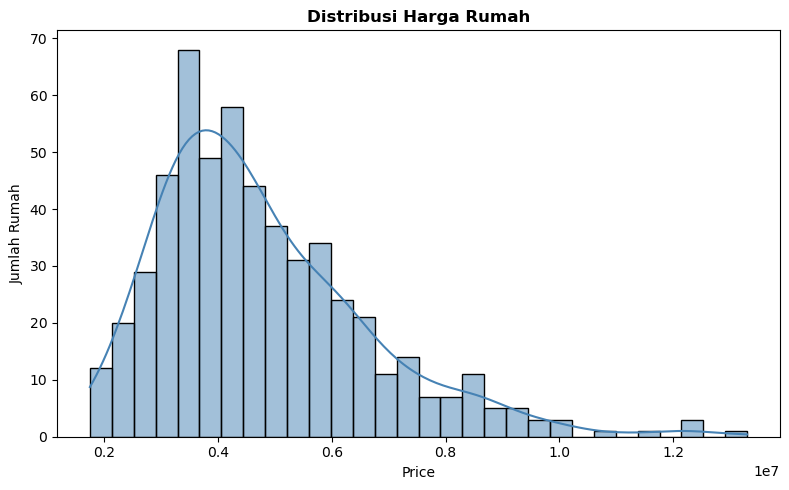

In [188]:
# Distribusi harga rumah
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='steelblue', bins=30, ax=ax)
ax.set_title('Distribusi Harga Rumah', fontweight='bold')
ax.set_xlabel('Price')
ax.set_ylabel('Jumlah Rumah')
plt.tight_layout()
plt.show()

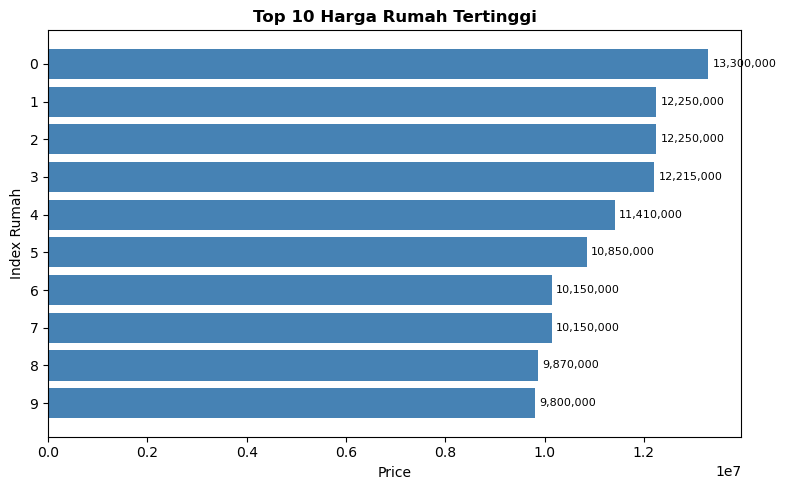

In [189]:
# Top 10 rumah termahal
top10 = df.nlargest(10, 'price')[['price', 'area', 'bedrooms']].reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top10.index.astype(str), top10['price'], color='steelblue')
ax.set_title('Top 10 Harga Rumah Tertinggi', fontweight='bold')
ax.set_xlabel('Price')
ax.set_ylabel('Index Rumah')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in bars.datavalues], padding=3, fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

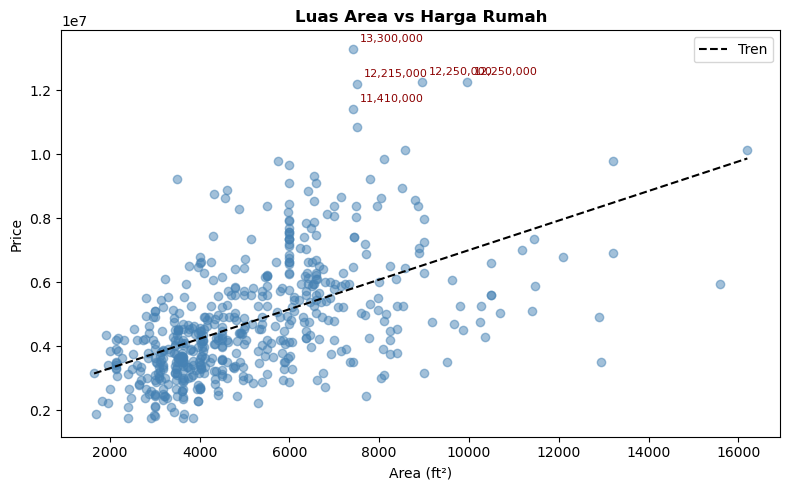

In [190]:
# Scatter plot luas area vs harga
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['area'], df['price'], color='steelblue', alpha=0.5)

# Garis tren
z = np.polyfit(df['area'], df['price'], 1)
x_line = np.linspace(df['area'].min(), df['area'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'k--', linewidth=1.5, label='Tren')

# Label top 5 rumah termahal
top5 = df.nlargest(5, 'price')
for _, row in top5.iterrows():
    ax.annotate(f"{row['price']:,}",
                xy=(row['area'], row['price']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='darkred')

ax.set_title('Luas Area vs Harga Rumah', fontweight='bold')
ax.set_xlabel('Area (ft²)')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()

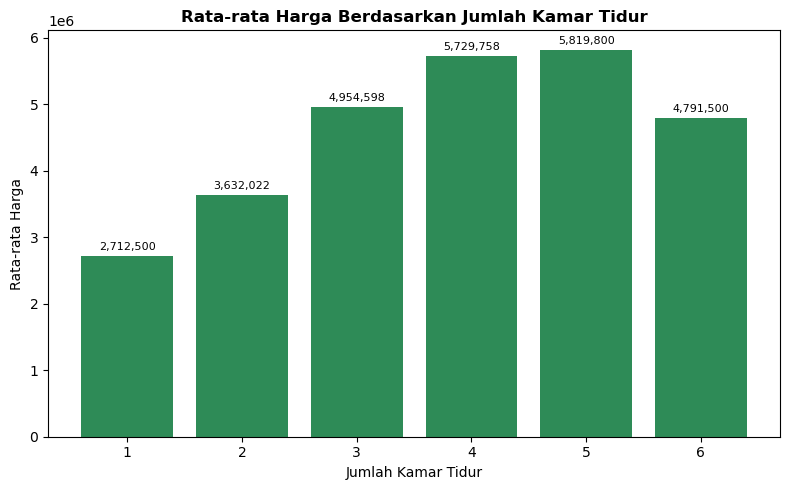

In [191]:
# Rata-rata harga berdasarkan jumlah kamar tidur
avg_price = df.groupby('bedrooms')['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_price['bedrooms'].astype(str), avg_price['price'], color='seagreen')
ax.set_title('Rata-rata Harga Berdasarkan Jumlah Kamar Tidur', fontweight='bold')
ax.set_xlabel('Jumlah Kamar Tidur')
ax.set_ylabel('Rata-rata Harga')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in bars.datavalues], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

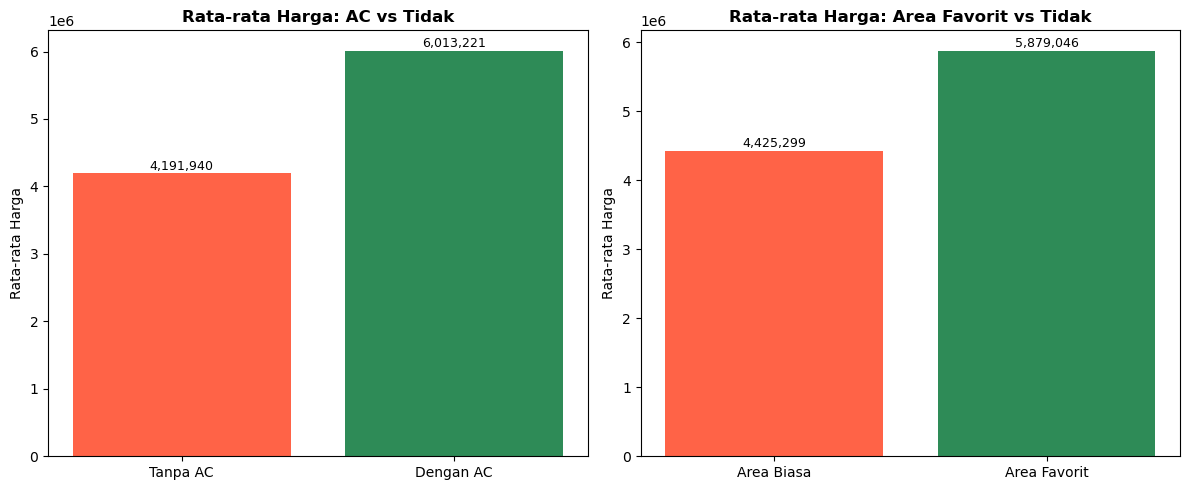

In [192]:
# Perbandingan rata-rata harga: AC vs tidak, area favorit vs tidak
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

avg_ac = df.groupby('airconditioning')['price'].mean()
axes[0].bar(['Tanpa AC', 'Dengan AC'], avg_ac.values, color=['tomato', 'seagreen'])
axes[0].set_title('Rata-rata Harga: AC vs Tidak', fontweight='bold')
axes[0].set_ylabel('Rata-rata Harga')
for i, v in enumerate(avg_ac.values):
    axes[0].text(i, v + 50000, f'{v:,.0f}', ha='center', fontsize=9)

avg_pref = df.groupby('prefarea')['price'].mean()
axes[1].bar(['Area Biasa', 'Area Favorit'], avg_pref.values, color=['tomato', 'seagreen'])
axes[1].set_title('Rata-rata Harga: Area Favorit vs Tidak', fontweight='bold')
axes[1].set_ylabel('Rata-rata Harga')
for i, v in enumerate(avg_pref.values):
    axes[1].text(i, v + 50000, f'{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Insight - EDA (Exploratory Data Analysis)

#### Insight 1: Distribusi Harga Rumah Condong ke Kanan (Right-Skewed)
- Mayoritas rumah berada di rentang harga 2 juta hingga 6 juta dengan puncak distribusi di sekitar 3 juta hingga 3.5 juta
- Terdapat rumah premium di atas 10 juta yang menjadi outlier, dengan harga tertinggi mencapai 13.300.000
- Top 10 rumah termahal semuanya berada di atas 9.8 juta, jauh di atas rata-rata dataset (4.766.729)

#### Insight 2: Luas Area Berkorelasi Positif dengan Harga
- Garis tren scatter plot menunjukkan semakin luas area rumah, semakin tinggi harganya
- Namun rumah termahal (13.300.000) berada di area sekitar 6.000 ft², bukan yang terluas dalam dataset
- Hal ini menunjukkan faktor lain seperti fasilitas dan lokasi turut menentukan harga selain luas area

#### Insight 3: Jumlah Kamar Tidur Mempengaruhi Harga secara Signifikan
- Rata-rata harga naik konsisten dari 1 kamar (2.712.500) hingga 5 kamar (5.819.800)
- Kenaikan terbesar terjadi dari 2 kamar ke 3 kamar, yaitu dari 3.632.022 menjadi 4.954.598
- Rumah dengan 6 kamar justru turun ke 4.791.500, kemungkinan karena data yang sangat sedikit

#### Insight 4: Fasilitas AC dan Lokasi Favorit Menaikkan Harga Signifikan
- Rumah dengan AC rata-rata berharga 6.013.221, sedangkan tanpa AC hanya 4.191.940, selisih sekitar 43%
- Rumah di area favorit rata-rata berharga 5.879.046, sedangkan area biasa hanya 4.425.299, selisih sekitar 33%
- Kedua fasilitas ini terbukti menjadi faktor penting yang mendongkrak nilai jual rumah

--------------

**5. Correlation Matrix**

> Buat correlation matrix, transformasi dulu seluruh data ke numerik agar tidak error saat masuk ke correlation matrix. Lalu berikan insight, apa yang kamu temukan dari correlation matrix dataset tersebut?

In [193]:
# Hitung matriks korelasi semua kolom
# Nilai mendekati 1  = korelasi positif kuat
# Nilai mendekati -1 = korelasi negatif kuat
# Nilai mendekati 0  = tidak ada korelasi
corr_matrix = df.corr().round(2)

print("Matriks Korelasi:")
print(corr_matrix)

Matriks Korelasi:
                  price  area  bedrooms  bathrooms  stories  mainroad  \
price              1.00  0.54      0.37       0.52     0.42      0.30   
area               0.54  1.00      0.15       0.19     0.08      0.29   
bedrooms           0.37  0.15      1.00       0.37     0.41     -0.01   
bathrooms          0.52  0.19      0.37       1.00     0.33      0.04   
stories            0.42  0.08      0.41       0.33     1.00      0.12   
mainroad           0.30  0.29     -0.01       0.04     0.12      1.00   
guestroom          0.26  0.14      0.08       0.13     0.04      0.09   
basement           0.19  0.05      0.10       0.10    -0.17      0.04   
hotwaterheating    0.09 -0.01      0.05       0.07     0.02     -0.01   
airconditioning    0.45  0.22      0.16       0.19     0.29      0.11   
parking            0.38  0.35      0.14       0.18     0.05      0.20   
prefarea           0.33  0.23      0.08       0.06     0.04      0.20   
furnishingstatus   0.30  0.17    

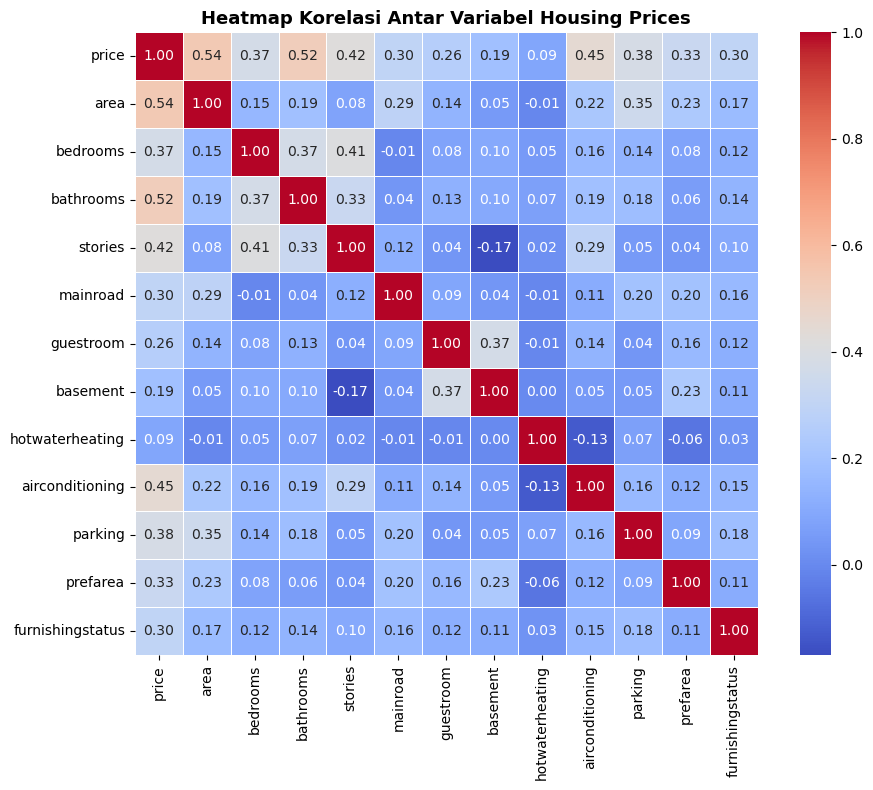

In [194]:
# Visualisasi heatmap korelasi
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Heatmap Korelasi Antar Variabel Housing Prices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight - Correlation Matrix

#### Fitur dengan Korelasi Tertinggi terhadap Harga (price)
- **area (0.54)**: korelasi positif paling kuat, semakin luas rumah semakin tinggi harganya
- **bathrooms (0.52)**: jumlah kamar mandi berkorelasi kuat, rumah dengan lebih banyak kamar mandi cenderung lebih mahal
- **airconditioning (0.45)**: keberadaan AC memberikan pengaruh cukup signifikan terhadap harga
- **stories (0.42)** dan **parking (0.38)**: jumlah lantai dan slot parkir juga berkontribusi positif terhadap harga

#### Fitur dengan Korelasi Lemah terhadap Harga
- **hotwaterheating (0.09)**: hampir tidak berkorelasi dengan harga, kemungkinan karena hanya 4.6% rumah yang memiliki fitur ini
- **basement (0.19)** dan **guestroom (0.26)**: berpengaruh kecil terhadap harga

#### Korelasi Antar Fitur yang Menarik
- **guestroom dan basement (0.37)**: rumah yang memiliki ruang tamu tambahan cenderung juga memiliki basement
- **stories dan basement (-0.17)**: rumah bertingkat justru cenderung tidak memiliki basement, kemungkinan karena desain bangunan yang berbeda
- **hotwaterheating dan airconditioning (-0.13)**: keduanya jarang dimiliki bersamaan dalam satu rumah

#### Kesimpulan Korelasi
- Fitur fisik rumah seperti **area, bathrooms, dan stories** adalah prediktor harga paling kuat
- Fasilitas **airconditioning dan prefarea** juga berkontribusi signifikan meskipun berupa variabel biner
- Tidak ada multikolinearitas tinggi antar fitur (tidak ada nilai korelasi di atas 0.8 selain diagonal), sehingga semua fitur aman digunakan untuk pemodelan

---------------

**6. Feature Engineering**



> Laksanakan Feature Engineering, buat variabel baru berdasarkan variabel yang sudah ada. Analisis hasil dari variabel baru tersebut.



In [195]:
# Membuat variabel baru: harga per ft² (price per square foot)
df['price_per_sqft'] = (df['price'] / df['area']).round(2)

print("Contoh price_per_sqft:")
print(df[['price', 'area', 'price_per_sqft']].head())

Contoh price_per_sqft:
      price  area  price_per_sqft
0  13300000  7420         1792.45
1  12250000  8960         1367.19
2  12250000  9960         1229.92
3  12215000  7500         1628.67
4  11410000  7420         1537.74


In [196]:
# Membuat variabel baru: total kamar (kamar tidur + kamar mandi)
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

print("Contoh total_rooms:")
print(df[['bedrooms', 'bathrooms', 'total_rooms']].head())

Contoh total_rooms:
   bedrooms  bathrooms  total_rooms
0         4          2            6
1         4          4            8
2         3          2            5
3         4          2            6
4         4          1            5


In [197]:
# Membuat variabel baru: skor fasilitas (jumlah fasilitas yang dimiliki rumah)
# airconditioning + guestroom + basement + hotwaterheating + prefarea
df['facility_score'] = df['airconditioning'] + df['guestroom'] + df['basement'] + df['hotwaterheating'] + df['prefarea']

print("Distribusi facility_score:")
print(df['facility_score'].value_counts().sort_index())

Distribusi facility_score:
facility_score
0    193
1    173
2    112
3     52
4     15
Name: count, dtype: int64


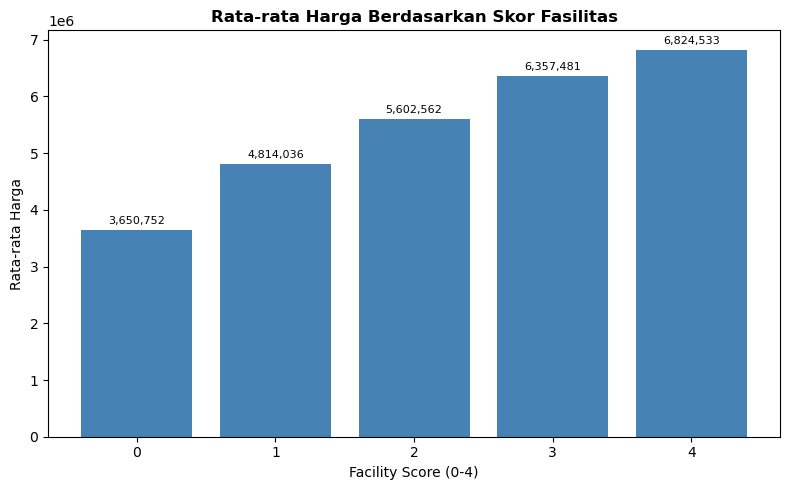

In [198]:
# Analisis rata-rata harga berdasarkan facility_score
avg_price_facility = df.groupby('facility_score')['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_price_facility['facility_score'].astype(str),
              avg_price_facility['price'],
              color='steelblue')
ax.set_title('Rata-rata Harga Berdasarkan Skor Fasilitas', fontweight='bold')
ax.set_xlabel('Facility Score (0-4)')
ax.set_ylabel('Rata-rata Harga')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in bars.datavalues], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

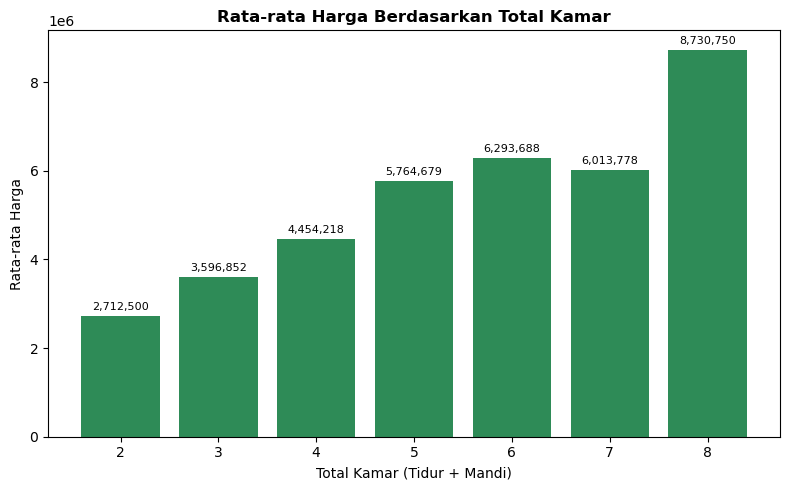

In [199]:
# Analisis rata-rata harga berdasarkan total_rooms
avg_price_rooms = df.groupby('total_rooms')['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_price_rooms['total_rooms'].astype(str),
              avg_price_rooms['price'],
              color='seagreen')
ax.set_title('Rata-rata Harga Berdasarkan Total Kamar', fontweight='bold')
ax.set_xlabel('Total Kamar (Tidur + Mandi)')
ax.set_ylabel('Rata-rata Harga')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in bars.datavalues], padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [200]:
# Tampilkan statistik variabel baru
print("=== Statistik Variabel Baru ===")
print(df[['price_per_sqft', 'total_rooms', 'facility_score']].describe().round(2))

=== Statistik Variabel Baru ===
       price_per_sqft  total_rooms  facility_score
count          545.00       545.00          545.00
mean           993.33         4.25            1.12
std            346.54         1.04            1.08
min            270.40         2.00            0.00
25%            745.37         4.00            0.00
50%            952.38         4.00            1.00
75%           1184.62         5.00            2.00
max           2640.00         8.00            4.00


### Insight - Feature Engineering

#### Variabel Baru yang Dibuat
- **price_per_sqft**: harga per ft² dihitung dari price dibagi area
- **total_rooms**: total kamar dihitung dari bedrooms ditambah bathrooms
- **facility_score**: skor fasilitas dari 0 sampai 4 berdasarkan jumlah fasilitas yang dimiliki (airconditioning, guestroom, basement, hotwaterheating, prefarea)

#### Insight 1: Semakin Banyak Fasilitas, Semakin Mahal Harga
- Rumah tanpa fasilitas (score 0) rata-rata berharga 3.650.752
- Rumah dengan 4 fasilitas (score 4) rata-rata berharga 6.824.533, naik hampir 87% dibanding tanpa fasilitas
- Kenaikan harga konsisten setiap penambahan 1 fasilitas, membuktikan bahwa fasilitas adalah faktor penentu harga yang kuat

#### Insight 2: Total Kamar Berkorelasi Kuat dengan Harga
- Rumah dengan 2 total kamar rata-rata berharga 2.712.500, sedangkan rumah dengan 8 total kamar mencapai 8.730.750
- Kenaikan paling signifikan terjadi dari 7 kamar (6.013.778) ke 8 kamar (8.730.750), selisih sekitar 2.7 juta
- Total kamar terbanyak pada dataset adalah 4 kamar (median), menunjukkan mayoritas rumah berukuran sedang

#### Insight 3: Harga per ft² Bervariasi Cukup Lebar
- Rata-rata harga per ft² adalah 993.33 dengan standar deviasi 346.54
- Harga per ft² terendah adalah 270.40 dan tertinggi 2640.00, selisih hampir 10 kali lipat
- Variasi ini menunjukkan bahwa luas area saja tidak cukup menentukan harga, faktor lokasi dan fasilitas ikut mempengaruhi nilai per ft² sebuah rumah


--------

**7. Kesimpulan**
> Berikan kesimpulan untuk dataset ini dan hasil dari analisis anda terhadap dataset yang dipakai.

## Kesimpulan Analisis Dataset Housing Prices

### Gambaran Dataset
Dataset Housing Prices terdiri dari 545 data rumah dengan 13 kolom yang mencakup fitur fisik
(area, bedrooms, bathrooms, stories, parking) dan fitur fasilitas (airconditioning, guestroom,
basement, hotwaterheating, prefarea, furnishingstatus). Dataset ini tergolong bersih karena
tidak ditemukan missing values maupun data duplikat.

### Faktor Utama Penentu Harga Rumah
Berdasarkan hasil analisis korelasi dan EDA, faktor yang paling berpengaruh terhadap harga adalah:
- **Area (0.54)**: luas rumah adalah prediktor harga terkuat dalam dataset ini
- **Bathrooms (0.52)**: jumlah kamar mandi mencerminkan kelas dan kenyamanan rumah
- **Airconditioning (0.45)**: keberadaan AC dapat menaikkan rata-rata harga hingga 43%
- **Stories (0.42)** dan **Parking (0.38)**: jumlah lantai dan slot parkir juga berkontribusi signifikan

### Temuan dari Feature Engineering
- Semakin tinggi **facility_score**, semakin mahal harga rumah, dari rata-rata 3.650.752 (score 0)
hingga 6.824.533 (score 4)
- **total_rooms** yang lebih banyak konsisten menghasilkan harga lebih tinggi, dengan puncak
rata-rata 8.730.750 untuk rumah dengan 8 total kamar
- **price_per_sqft** bervariasi lebar (270 hingga 2640), membuktikan luas bukan satu-satunya
penentu nilai rumah

### Kesimpulan Akhir
Harga rumah dalam dataset ini ditentukan oleh kombinasi antara ukuran fisik rumah dan
kelengkapan fasilitasnya. Rumah dengan area luas, banyak kamar mandi, dilengkapi AC,
dan berada di area favorit (prefarea) cenderung memiliki harga jauh di atas rata-rata.
Dataset ini berpotensi baik untuk digunakan dalam pemodelan prediksi harga rumah
menggunakan machine learning karena seluruh fitur sudah dalam format numerik dan
tidak ada data yang hilang.